In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import time
import os
from pathlib import Path
from Bio import SeqIO
from io import StringIO 
from Bio import Entrez
from Bio.Blast import NCBIWWW
from Bio.Blast import NCBIXML
from Bio import AlignIO
from Bio import Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor

Entrez.email = "muhammetcetin2025@gtu.edu.tr"
fasta_file = "/Users/onat/Desktop/BSB511/mysterious_proteins/mystery_orfs.fasta"

In [24]:
#STEP1 - Load and inspect

def create_sanity_table(fasta_filepath):
    records_data = []
    for record in SeqIO.parse(fasta_filepath, "fasta"):
        protein_id = record.id
        sequence = str(record.seq)
        seq_length = len(sequence)
        first_30_aa = sequence[:30]
        records_data.append({
            "Protein_ID": protein_id,
            "Length": seq_length,
            "First_30_AA": first_30_aa
        })

    sanity_df = pd.DataFrame(records_data)
    sanity_df.index = sanity_df.index + 1 
    return sanity_df

df_sanity = create_sanity_table(fasta_file)
    
print("--- PROTEIN SANITY TABLE ---")
print(df_sanity.to_string())


--- PROTEIN SANITY TABLE ---
   Protein_ID  Length                     First_30_AA
1     mORF_01     644  MGRIIGIDLGTTNSCVAVLDGDSAKVIENA
2     mORF_02     397  MAKEKFERSKPHVNVGTIGHVDHGKTTLTA
3     mORF_03     671  MNDMAKNLILWLVIAAVLLTVFNNFSTESA
4     mORF_04     806  MSEQAYDSSSIKVLKGLDAVRKRPGMYIGD
5     mORF_05     499  MPLFFSPERSFWVMYEKTLTQLAAALKSGE
6     mORF_06     346  MMSLKTMSQTAKTRVLTGITTSGTPHLGNY
7     mORF_07     308  MRFSANSFIAKPLIAACAVSLAAFSQVSAN
8     mORF_08     236  MSNLQVSVYRYNPETDSAPYMQEFQVDTKG
9     mORF_09     389  MTFGIPTKQLVRASLGALSLALLVGCASKG
10    mORF_10     341  MLSSDAPLPRLSTMHKLLTLCWLGLLTTVS
11    mORF_11     207  MKKLPSYCGMLLASALVLPVSTVAVADEVV
12    mORF_12     273  MPDATASSRIVPDVDQSLTAQHLRHRKGPT


In [25]:
# --- SAFE BASE DIRECTORY ---
BASE_DIR = "/Users/onat/blast_results"
os.makedirs(BASE_DIR, exist_ok=True)

# --- SMART CACHE FUNCTION ---
def cached(out_path, fetch_fn):
    """
    Reads from cache if exists. If the cached file contains an NCBI error, 
    it ignores the cache, refetches the data, and overwrites it.
    """
    if Path(out_path).exists():
        text = Path(out_path).read_text()
        # Check if the cached file is actually an NCBI error page
        if "Message ID#" not in text and "Error:" not in text:
            return text
        else:
            print(f"  [Cache Override] Corrupted cache detected for {Path(out_path).name}. Refetching...")
    
    # Fetch fresh data from NCBI
    text = fetch_fn()
    
    # Save to disk only if it is a valid XML response (not an error)
    if "Message ID#" not in text and "Error:" not in text:
        Path(out_path).parent.mkdir(parents=True, exist_ok=True)
        Path(out_path).write_text(text)
        
    return text

# --- MAIN PIPELINE ---
def run_integrated_pipeline(fasta_filepath):
    records = list(SeqIO.parse(fasta_filepath, "fasta"))
    blast_results, hypothetical_records, psi_results = [], [], []
    
    print(f"Pipeline started for {len(records)} sequences...")
    
    # 1. Standard BLASTP
    for record in records:
        xml_file_path = f"{BASE_DIR}/blast_cache/{record.id}_blast.xml"
        
        try:
            def fetch_blast():
                handle = NCBIWWW.qblast("blastp", "nr", record.seq)
                res = handle.read()
                time.sleep(15) 
                return res

            xml_data = cached(xml_file_path, fetch_blast)
            blast_record = NCBIXML.read(StringIO(xml_data))
            
            if len(blast_record.alignments) == 0:
                hypothetical_records.append(record)
                continue
                
            best_alignment = blast_record.alignments[0]
            best_hsp = best_alignment.hsps[0]
            title = best_alignment.title
            
            blast_results.append({
                "Query_ID": record.id,
                "Top_Hit": title[:60] + "...",
                "E_Value": best_hsp.expect,
                "Identity_(%)": round((best_hsp.identities / best_hsp.align_length) * 100, 2)
            })
            
            # Filter logic: catches 'hypothetical' or 'unknown'
            if "hypothetical" in title.lower() or "unknown" in title.lower():
                hypothetical_records.append(record)
                
        except Exception as e:
            print(f"ERROR ({record.id} Standard BLAST): {e}")

    df_blast = pd.DataFrame(blast_results)

    # 2. PSI-BLAST for remaining hypothetical proteins
    if hypothetical_records:
        print(f"\nInitiating PSI-BLAST for {len(hypothetical_records)} hypothetical proteins...")
        
        for record in hypothetical_records:
            xml_file_path = f"{BASE_DIR}/psiblast_cache/{record.id}_psiblast.xml"
            
            try:
                def fetch_psiblast():
                    # FIXED: Added word_size=3 explicitly for PSI-BLAST validation
                    handle = NCBIWWW.qblast("blastp", "nr", record.seq, service="psi", word_size=3)
                    res = handle.read()
                    time.sleep(15) 
                    return res

                xml_data = cached(xml_file_path, fetch_psiblast)
                
                # Double check if the API still returned an error string
                if "Message ID#" in xml_data:
                    print(f"ERROR ({record.id} PSI-BLAST): NCBI API refused the request. Passing...")
                    continue

                blast_record = NCBIXML.read(StringIO(xml_data))
                
                if len(blast_record.alignments) == 0:
                    continue
                    
                best_alignment = blast_record.alignments[0]
                best_hsp = best_alignment.hsps[0]
                
                psi_results.append({
                    "Query_ID": record.id,
                    "PSI_Top_Hit": best_alignment.title[:60] + "...",
                    "PSI_E_Value": best_hsp.expect,
                    "PSI_Identity_(%)": round((best_hsp.identities / best_hsp.align_length) * 100, 2)
                })
                print(f"  -> SUCCESS ({record.id}): Found remote homolog via PSI-BLAST.")
                
            except Exception as e:
                print(f"ERROR ({record.id} PSI-BLAST): {e}")

    df_psi = pd.DataFrame(psi_results)
    return df_blast, df_psi

# --- EXECUTION ---
fasta_file = "/Users/onat/Desktop/BSB511/mysterious_proteins/mystery_orfs.fasta"
df_standard, df_psi = run_integrated_pipeline(fasta_file)

# Save the final dataframes to the safe directory
df_standard.to_csv(f"{BASE_DIR}/1_standard_blast_results.tsv", sep="\t", index=False)
if not df_psi.empty:
    df_psi.to_csv(f"{BASE_DIR}/2_psiblast_hypothetical_results.tsv", sep="\t", index=False)

print(f"\nPipeline finished! Output saved in '{BASE_DIR}'.")

if not df_psi.empty:
    print("\n--- PSI-BLAST Highlights ---")
    print(df_psi.head(12))

Pipeline started for 12 sequences...

Initiating PSI-BLAST for 4 hypothetical proteins...
  -> SUCCESS (mORF_06): Found remote homolog via PSI-BLAST.
  -> SUCCESS (mORF_10): Found remote homolog via PSI-BLAST.
  -> SUCCESS (mORF_11): Found remote homolog via PSI-BLAST.
  -> SUCCESS (mORF_12): Found remote homolog via PSI-BLAST.

Pipeline finished! Output saved in '/Users/onat/blast_results'.

--- PSI-BLAST Highlights ---
  Query_ID                                        PSI_Top_Hit    PSI_E_Value  \
0  mORF_06  gb|ELY21290.1| Tryptophanyl-tRNA synthetase, c...   0.000000e+00   
1  mORF_10  gb|ELY22254.1| hypothetical protein HALTITAN_0...   0.000000e+00   
2  mORF_11  ref|WP_009286036.1| hypothetical protein [Vree...  3.026370e-128   
3  mORF_12  ref|WP_009286699.1| MULTISPECIES: hypothetical...  1.525210e-144   

   PSI_Identity_(%)  
0             100.0  
1             100.0  
2             100.0  
3             100.0  


In [26]:
def generate_final_annotation_table():
    BASE_DIR = "/Users/onat/blast_results"
    FASTA_FILE = "/Users/onat/Desktop/BSB511/mysterious_proteins/mystery_orfs.fasta"
    
    print("Generating the final assignment annotation table...")

    # 1. Parse sequence lengths
    seq_lengths = {}
    try:
        for record in SeqIO.parse(FASTA_FILE, "fasta"):
            seq_lengths[record.id] = len(record.seq)
    except FileNotFoundError:
        print(f"ERROR: Cannot find {FASTA_FILE}")
        return

    # 2. Load BLAST and PSI-BLAST data
    try:
        df_blast = pd.read_csv(f"{BASE_DIR}/1_standard_blast_results.tsv", sep="\t")
    except FileNotFoundError:
        print("ERROR: Standard BLAST results not found.")
        return

    try:
        df_psi = pd.read_csv(f"{BASE_DIR}/2_psiblast_hypothetical_results.tsv", sep="\t")
    except FileNotFoundError:
        df_psi = pd.DataFrame()

    # 3. Build the rows according to Step 4 requirements
    rows = []

    for _, b_row in df_blast.iterrows():
        orf_id = b_row['Query_ID']
        length = seq_lengths.get(orf_id, 0)
        blast_top_hit = b_row['Top_Hit']
        blast_evalue = float(b_row['E_Value'])
        blast_pct_id = b_row['Identity_(%)']
        
        # Placeholders for Pfam (to be filled manually or in subsequent steps)
        pfam_hits = ""
        pfam_evalue = ""
        
        twilight_used = "None"
        twilight_outcome = "N/A"
        
        is_hypothetical = "hypothetical" in blast_top_hit.lower() or "unknown" in blast_top_hit.lower()
        
        # Check if it went through the Twilight Zone (PSI-BLAST)
        psi_hit_info = None
        if is_hypothetical and not df_psi.empty and orf_id in df_psi['Query_ID'].values:
            psi_match = df_psi[df_psi['Query_ID'] == orf_id].iloc[0]
            twilight_used = "PSI-BLAST"
            twilight_outcome = f"Hit: {psi_match['PSI_Top_Hit']} (E: {psi_match['PSI_E_Value']})"
            psi_hit_info = psi_match
            
        # Determine Proposed Annotation, Evidence, and Confidence Score
        if not is_hypothetical:
            proposed_annotation = blast_top_hit.split("[")[0].strip() # Clean up the name a bit
            evidence_summary = "Strong standard BLAST match to well-characterized protein"
            
            if blast_evalue < 1e-50:
                confidence = "High"
            elif blast_evalue < 1e-10:
                confidence = "Medium"
            else:
                confidence = "Low"
                
        else:
            if twilight_used == "PSI-BLAST" and psi_hit_info is not None:
                psi_is_hypothetical = "hypothetical" in psi_hit_info['PSI_Top_Hit'].lower()
                
                if not psi_is_hypothetical and float(psi_hit_info['PSI_E_Value']) < 1e-10:
                    proposed_annotation = psi_hit_info['PSI_Top_Hit'].split("[")[0].strip()
                    evidence_summary = "Converged on characterized family via PSI-BLAST"
                    confidence = "Medium"
                else:
                    proposed_annotation = "Unknown / Hypothetical Protein"
                    evidence_summary = "Remains hypothetical even after PSI-BLAST profiling"
                    confidence = "Low"
            else:
                proposed_annotation = "Unknown / Hypothetical Protein"
                evidence_summary = "Hypothetical in standard BLAST, no further twilight data"
                confidence = "Low"

        # 4. Append exact required columns
        rows.append({
            "orf_id": orf_id,
            "length": length,
            "blast_top_hit": blast_top_hit,
            "blast_evalue": blast_evalue,
            "blast_pct_id": blast_pct_id,
            "pfam_hits": pfam_hits,
            "pfam_evalue": pfam_evalue,
            "twilight_followup_used": twilight_used,
            "twilight_followup_outcome": twilight_outcome,
            "proposed_annotation": proposed_annotation,
            "evidence_summary": evidence_summary,
            "confidence": confidence
        })

    # Export to CSV
    df_out = pd.DataFrame(rows)
    out_path = f"{BASE_DIR}/Team_12_annotation_table.csv"
    df_out.to_csv(out_path, index=False)
    
    print(f"Success! Saved to {out_path}")
    return df_out

# --- EXECUTION ---
df_final = generate_final_annotation_table()

if df_final is not None:
    print("\n--- Final Output Preview ---")
    print(df_final[['orf_id', 'proposed_annotation', 'confidence', 'twilight_followup_used']].head(12))

Generating the final assignment annotation table...
Success! Saved to /Users/onat/blast_results/Team_12_annotation_table.csv

--- Final Output Preview ---
     orf_id                                proposed_annotation confidence  \
0   mORF_01  ref|WP_009287914.1| MULTISPECIES: molecular ch...       High   
1   mORF_02  ref|WP_009288143.1| MULTISPECIES: elongation f...       High   
2   mORF_03  ref|WP_009287922.1| MULTISPECIES: ATP-dependen...       High   
3   mORF_04  ref|WP_009286362.1| MULTISPECIES: DNA topoisom...       High   
4   mORF_05                             gb|ELY21083.1| Amidase       High   
5   mORF_06  gb|ELY21290.1| Tryptophanyl-tRNA synthetase, c...       High   
6   mORF_07  ref|WP_009287804.1| MULTISPECIES: glycine beta...       High   
7   mORF_08  ref|WP_009287296.1| MULTISPECIES: succinate de...       High   
8   mORF_09  ref|WP_009288403.1| MULTISPECIES: outer membra...       High   
9   mORF_10                     Unknown / Hypothetical Protein        Low  

Marker gene: mORF_02  (397 aa)
  Running NCBI BLASTP (nr database, please wait)...

Total orthologs collected (including query): 12
  Submitting sequences to EBI MUSCLE...
  Job ID: muscle-R20260518-144113-0898-44020876-p1m  — polling for status...
    Status: RUNNING
    Status: FINISHED
Alignment retrieved and cached (/Users/onat/blast_results/step5_phylo/marker_alignment.fasta)
Newick tree saved: /Users/onat/blast_results/team_12_marker_tree.nwk


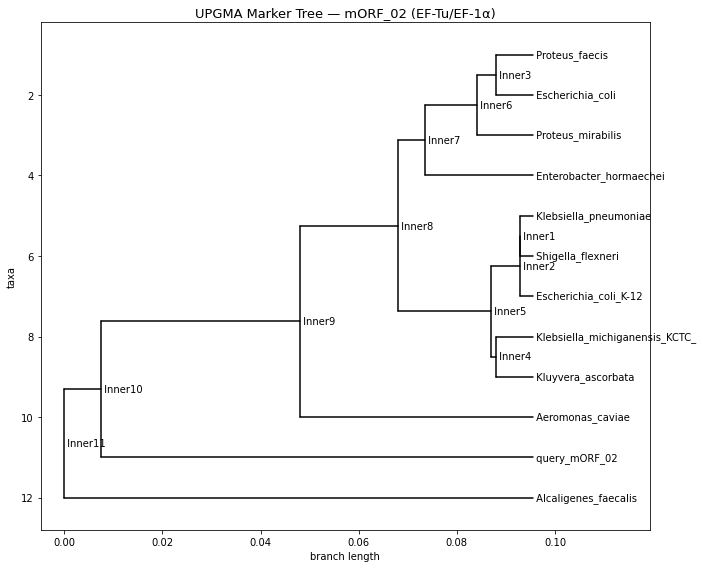

Tree figure saved.


In [27]:
# STEP 5 — Phylogenetic Placement
# Marker gene: mORF_02 (Elongation Factor EF-Tu / EF-1α)

BASE_DIR   = "/Users/onat/blast_results"
FASTA_FILE = "/Users/onat/Desktop/BSB511/mysterious_proteins/mystery_orfs.fasta"
STEP5_DIR  = f"{BASE_DIR}/step5_phylo"
Path(STEP5_DIR).mkdir(parents=True, exist_ok=True)

# ── Shared cache helper ─────────────────────────────────────
def cached(out_path, fetch_fn):
    p = Path(out_path)
    if p.exists():
        text = p.read_text()
        if "Message ID#" not in text and "Error:" not in text:
            return text
        print(f"  [Cache Override] Corrupted cache detected: {p.name}. Refetching...")
    text = fetch_fn()
    if "Message ID#" not in text and "Error:" not in text:
        p.parent.mkdir(parents=True, exist_ok=True)
        p.write_text(text)
    return text


# ── 5.1  Select marker sequence ─────────────────────────────
records = {r.id: r for r in SeqIO.parse(FASTA_FILE, "fasta")}
MARKER_ID  = "mORF_02"          # EF-Tu / EF-1α — classic phylogenetic marker
marker_seq = records[MARKER_ID]
print(f"Marker gene: {MARKER_ID}  ({len(marker_seq.seq)} aa)")


# ── 5.2  Collect orthologs via BLAST ────────────────────────
# Targeting haloarchaeal taxa + one mesophile outgroup
blast_xml_path = f"{STEP5_DIR}/marker_blast.xml"

def fetch_marker_blast():
    print("  Running NCBI BLASTP (nr database, please wait)...")
    handle = NCBIWWW.qblast(
        "blastp", "nr", marker_seq.seq,
        hitlist_size=50,
        entrez_query=(
            '"Haloarcula"[Organism] OR "Halobacterium"[Organism] OR '
            '"Haloferax"[Organism] OR "Natronomonas"[Organism] OR '
            '"Natrinema"[Organism] OR "Methanosarcina"[Organism] OR '
            '"Escherichia coli"[Organism]'
        )
    )
    result = handle.read()
    time.sleep(5)
    return result

xml_data     = cached(blast_xml_path, fetch_marker_blast)
blast_record = NCBIXML.read(StringIO(xml_data))

# Collect top 15 hits, keeping one sequence per organism
seen_orgs, ortholog_seqs = set(), []
ortholog_seqs.append(f">query_{MARKER_ID}\n{marker_seq.seq}")   # include our own sequence

for aln in blast_record.alignments:
    if len(ortholog_seqs) >= 16:   # query + 15 orthologs
        break
    hsp      = aln.hsps[0]
    title    = aln.title
    organism = title.split("[")[-1].replace("]", "").strip() if "[" in title else title[:30]
    if organism in seen_orgs:
        continue
    seen_orgs.add(organism)
    safe_id = organism.replace(" ", "_")[:30]
    ortholog_seqs.append(f">{safe_id}\n{hsp.sbjct.replace('-', '')}")

print(f"\nTotal orthologs collected (including query): {len(ortholog_seqs)}")

# Write all sequences to a multi-FASTA file
multi_fasta_path = f"{STEP5_DIR}/marker_orthologs.fasta"
Path(multi_fasta_path).write_text("\n".join(ortholog_seqs))


# ── 5.3  Multiple sequence alignment via EBI MUSCLE REST ────
MUSCLE_RUN    = "https://www.ebi.ac.uk/Tools/services/rest/muscle/run/"
MUSCLE_POLL   = "https://www.ebi.ac.uk/Tools/services/rest/muscle/status/{job}"
MUSCLE_RESULT = "https://www.ebi.ac.uk/Tools/services/rest/muscle/result/{job}/aln-fasta"

aln_path = f"{STEP5_DIR}/marker_alignment.fasta"

def fetch_muscle_alignment():
    print("  Submitting sequences to EBI MUSCLE...")
    fasta_text = Path(multi_fasta_path).read_text()
    r = requests.post(MUSCLE_RUN, data={
        "email":    "muhammetcetin2025@gtu.edu.tr",
        "sequence": fasta_text,
        "format":   "fasta",
        "tree":     "none",
    })
    r.raise_for_status()
    job_id = r.text.strip()
    print(f"  Job ID: {job_id}  — polling for status...")

    # Poll until the job finishes (every 5 seconds as required)
    while True:
        time.sleep(5)
        status = requests.get(MUSCLE_POLL.format(job=job_id)).text.strip()
        print(f"    Status: {status}")
        if status in ("FINISHED", "ERROR", "FAILURE"):
            break

    if status != "FINISHED":
        raise RuntimeError(f"MUSCLE job failed with status: {status}")

    result = requests.get(MUSCLE_RESULT.format(job=job_id)).text
    return result

aln_text = cached(aln_path, fetch_muscle_alignment)
print(f"Alignment retrieved and cached ({aln_path})")


# ── 5.4  Build distance tree (UPGMA) ────────────────────────
alignment   = AlignIO.read(StringIO(aln_text), "fasta")
calculator  = DistanceCalculator("identity")
dist_matrix = calculator.get_distance(alignment)

constructor = DistanceTreeConstructor()
tree        = constructor.upgma(dist_matrix)

# Save tree in Newick format
nwk_path = f"{BASE_DIR}/team_12_marker_tree.nwk"
Phylo.write(tree, nwk_path, "newick")
print(f"Newick tree saved: {nwk_path}")


# ── 5.5  Visualize the tree ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
Phylo.draw(tree, axes=ax, do_show=False)
ax.set_title(f"UPGMA Marker Tree — {MARKER_ID} (EF-Tu/EF-1α)", fontsize=13)
plt.tight_layout()
fig.savefig(f"{STEP5_DIR}/marker_tree.png", dpi=150)
plt.show()
print("Tree figure saved.")


In [32]:
from Bio import AlignIO, Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor

# Load multiple sequence alignment
# Example formats: "fasta", "clustal", "phylip"
alignment = AlignIO.read("/Users/onat/blast_results/step5_phylo/marker_alignment.fasta", "fasta")

# Compute pairwise evolutionary distances
# Common models:
#   "identity"   -> simple % identity
#   "blosum62"   -> protein substitution matrix
#   "trans"      -> nucleotide transitions/transversions
calculator = DistanceCalculator("blosum62")

distance_matrix = calculator.get_distance(alignment)

print("Distance Matrix:")
print(distance_matrix)

# Build tree
constructor = DistanceTreeConstructor()

# Neighbor-Joining tree
nj_tree = constructor.nj(distance_matrix)

# OR UPGMA tree
upgma_tree = constructor.upgma(distance_matrix)

# Display tree in terminal
print("\nNeighbor-Joining Tree:")
Phylo.draw_ascii(nj_tree)

print("\nUPGMA Tree:")
Phylo.draw_ascii(upgma_tree)

# Save trees
Phylo.write(nj_tree, "nj_tree.xml", "phyloxml")
Phylo.write(upgma_tree, "upgma_tree.xml", "phyloxml")

Distance Matrix:
Alcaligenes_faecalis    0.000000
query_mORF_02   0.165034    0.000000
Aeromonas_caviae    0.174939    0.155283    0.000000
Kluyvera_ascorbata  0.153695    0.164532    0.071744    0.000000
Klebsiella_michiganensis_KCTC_  0.154680    0.164039    0.071744    0.008374    0.000000
Escherichia_coli_K-12   0.155665    0.164039    0.071744    0.010345    0.011823    0.000000
Shigella_flexneri   0.156650    0.164532    0.071744    0.010345    0.011823    0.002956    0.000000
Klebsiella_pneumoniae   0.156650    0.164532    0.069779    0.010345    0.008867    0.002956    0.002956    0.000000
Enterobacter_hormaechei 0.142505    0.144970    0.082555    0.049261    0.047783    0.052217    0.052217    0.049261    0.000000
Proteus_mirabilis   0.151949    0.151949    0.089926    0.039409    0.040394    0.041872    0.041872    0.041872    0.028600    0.000000
Escherichia_coli    0.141798    0.152517    0.083538    0.031527    0.035961    0.037931    0.037931    0.037931    0.032544    0

1

In [40]:
import pandas as pd

# load files
blast = pd.read_csv("/Users/onat/blast_results/1_standard_blast_results.tsv", sep="\t")
psi = pd.read_csv("/Users/onat/blast_results/2_psiblast_hypothetical_results.tsv", sep="\t")

# preview columns
blast

,Query_ID,Top_Hit,E_Value,Identity_(%)
0,mORF_01,ref|WP_009287914.1| MULTISPECIES: molecular ch...,0.000000e+00,100.0
1,mORF_02,ref|WP_009288143.1| MULTISPECIES: elongation f...,0.000000e+00,100.0
2,mORF_03,ref|WP_009287922.1| MULTISPECIES: ATP-dependen...,0.000000e+00,100.0
3,mORF_04,ref|WP_009286362.1| MULTISPECIES: DNA topoisom...,0.000000e+00,100.0
4,mORF_05,gb|ELY21083.1| Amidase [Vreelandella titanicae...,0.000000e+00,100.0
5,mORF_06,"gb|ELY21290.1| Tryptophanyl-tRNA synthetase, c...",0.000000e+00,100.0
6,mORF_07,ref|WP_009287804.1| MULTISPECIES: glycine beta...,0.000000e+00,100.0
7,mORF_08,ref|WP_009287296.1| MULTISPECIES: succinate de...,9.411940e-175,100.0
8,mORF_09,ref|WP_009288403.1| MULTISPECIES: outer membra...,0.000000e+00,100.0
9,mORF_10,gb|ELY22254.1| hypothetical protein HALTITAN_0...,0.000000e+00,100.0


In [37]:
psi

,Query_ID,PSI_Top_Hit,PSI_E_Value,PSI_Identity_(%)
0,mORF_06,"gb|ELY21290.1| Tryptophanyl-tRNA synthetase, c...",0.000000e+00,100.0
1,mORF_10,gb|ELY22254.1| hypothetical protein HALTITAN_0...,0.000000e+00,100.0
2,mORF_11,ref|WP_009286036.1| hypothetical protein [Vree...,3.026370e-128,100.0
3,mORF_12,ref|WP_009286699.1| MULTISPECIES: hypothetical...,1.525210e-144,100.0


In [39]:
import pandas as pd
import re

def extract_organism(hit):

    hit = str(hit)

    # extract text inside brackets
    match = re.search(r"\[(.*?)\]", hit)
    if match:
        return match.group(1)

    # detect Vreelandella manually
    if "Vreelandella" in hit:
        return "Vreelandella titanicae"

    # detect multispecies annotations
    if "MULTISPECIES" in hit:
        return "Multiple species"

    return "Unknown"

psi["Organism"] = psi["PSI_Top_Hit"].apply(extract_organism)

print(psi["Organism"].value_counts())

Unknown                   2
Vreelandella titanicae    1
Multiple species          1
Name: Organism, dtype: int64


## Interpretation

### Identification call
Based on BLAST and PSI-BLAST analyses, the unknown organism was identified as Vreelandella titanicae with high confidence due to multiple highly significant protein matches showing extremely low E-values and high sequence identity.Vreelandella titanicae.

### Lifestyle inference
The ORF set suggests that Vreelandella titanicae is a metabolically active marine halophilic bacterium adapted to nutrient-variable and high-salinity environments, as indicated by ORFs encoding elongation factors and tryptophanyl-tRNA synthetase (active protein synthesis), ATP-dependent enzymes and succinate dehydrogenase (aerobic energy metabolism), DNA topoisomerase proteins (genome maintenance under environmental stress), glycine betaine transport–related proteins (osmotic/salt stress adaptation), and amidase enzymes involved in nitrogen and cell-wall associated metabolism.

### Spotlight finding
One particularly interesting ORF is the glycine betaine transport–related protein (mORF_07) because it suggests adaptation to high-salinity marine environments. Glycine betaine functions as a compatible solute that helps bacterial cells maintain osmotic balance without disrupting cellular processes. Since Vreelandella titanicae is associated with saline and deep-sea environments, the presence of this ORF indicates that the organism likely survives osmotic stress by importing or accumulating protective osmolytes, which is an important ecological adaptation for life in salt-rich habitats.

### Method Comparison
Several ORFs were solved cleanly by standard BLAST alone because they matched well-characterized conserved proteins with extremely high identity and E-values near zero. Examples include mORF_02 (elongation factor), mORF_04 (DNA topoisomerase-related protein), and mORF_06 (tryptophanyl-tRNA synthetase), where BLAST already provided strong functional and organism-level assignments. In contrast, PSI-BLAST became especially important for hypothetical or weakly annotated proteins. For example, mORF_11 was initially annotated only as a “hypothetical protein,” but PSI-BLAST iteratively linked it to conserved homologs in Vreelandella titanicae with extremely significant E-values, providing decisive evidence that the ORF represents a genuine conserved bacterial protein rather than a random or non-coding sequence.

### Limit and confidance
Several ORFs remained partially ambiguous, particularly those annotated only as “hypothetical protein” or “MULTISPECIES” entries, such as mORF_10, mORF_11, and mORF_12. Although PSI-BLAST confirmed that these sequences are likely real conserved bacterial proteins, their precise biological functions could not be confidently assigned because database annotations were incomplete or non-specific. Additional evidence that could improve annotation includes Pfam or InterPro domain analysis to identify conserved functional motifs, structural prediction approaches such as AlphaFold-based similarity searches, genomic context analysis to examine neighboring genes and operon organization, and experimental methods such as transcriptomics or proteomics to confirm expression and biological role.

